# Introduction to Qiskit

In this notebook we will explore how we can program quantum gates and quantum circuits with Qiskit and even how we can execute them on simulators and real quantum computers using Qiskit patterns. Later we will introduce different ways of encoding information and we will finish with a Bonus example of Quantum Teleportation.

## Before you begin

Follow the [Install and set up](https://docs.quantum.ibm.com/guides/install-qiskit) instructions if you haven't already, including the steps to [Set up to use IBM Quantum™ Platform](https://docs.quantum.ibm.com/guides/setup-channel#set-up-to-use-ibm-quantum-platform).

It is recommended that you use the [Jupyter](https://jupyter.org/install) development environment to interact with quantum computers. Be sure to install the recommended extra visualization support (`'qiskit[visualization]'`). You'll also need the `matplotlib` package for the second part of this example.

To learn about quantum computing in general, visit the [Basics of quantum information course](https://learning.quantum.ibm.com/course/basics-of-quantum-information) in IBM Quantum Learning

## Imports

In [2]:
# Import necessary modules for this notebook
import time
import qiskit

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector, plot_state_qsphere
from qiskit_aer import AerSimulator
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.visualization import plot_histogram
print(qiskit.__version__)

2.3.0


To execute your quantum circuits on hardware you need to first set up your account.
You can do it as follows:

1. Go to the [upgraded IBM Quantum&reg; Platform](https://quantum.cloud.ibm.com/).
2. Go to the top right corner (as shown in the above picture), create your API token, and copy it to a secure location.
3. In the next cell, replace `deleteThisAndPasteYourAPIKeyHere` with your API key.
4. Go to the bottom left corner (as shown in the above picture) and **create your instance**. Make sure to choose the open plan.
5. After the instance is created, copy its associated CRN code. You may need to refresh to see the instance.
6. In the cell below, replace `deleteThisAndPasteYourCRNHere` with your CRN code.

See [this guide](https://quantum.cloud.ibm.com/docs/guides/cloud-setup) for more details on how to set up your IBM Cloud&reg; account.

<div class="alert alert-block alert-warning">
    
⚠️ **Note:** Treat your API key as you would a secure password. See the [Cloud setup](https://quantum.cloud.ibm.com/docs/guides/cloud-setup#cloud-save) guide for more information about using your API key in both secure and untrusted environments.
</div>

In [3]:
your_api_key = "zfUkIMg-_-azJTmk5We0IU2N6qhxic1r9_yC1zN0Xygu"
your_crn = "crn:v1:bluemix:public:quantum-computing:eu-de:a/cb804b30dfcb48b890393bfd6e41e9c2:e495fc76-27a7-45bf-8289-d7ac75454ff5::"

QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token=your_api_key,
    instance=your_crn,
    overwrite=True
)

# 1. Quantum Gates and Quantum Circuits
Quantum circuits are models for quantum computation in which a computation is a sequence of quantum gates. Let's take a look at some of the popular quantum gates.

### X Gate
An X gate equates to a rotation around the X-axis of the Bloch sphere by $\pi$ radians.
It maps $|0\rangle$ to $|1\rangle$ and $|1\rangle$ to $|0\rangle$. It is the quantum equivalent of the NOT gate for classical computers and is sometimes called a bit-flip.

$X = \begin{pmatrix}
0 & 1 \\
1 & 0 \\
\end{pmatrix}$

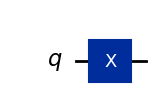

In [6]:
# Let's apply an X-gate on a |0> qubit
qc = QuantumCircuit(1)
qc.x(0)
qc.draw(output='mpl')

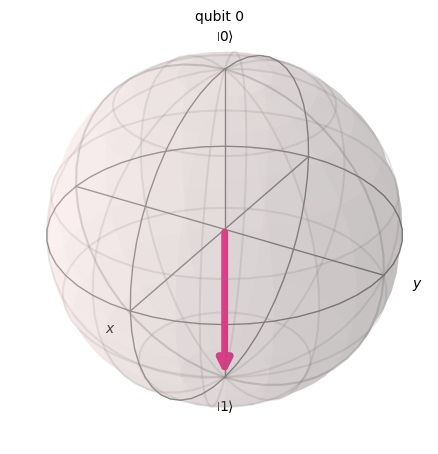

In [7]:
# Let's see Bloch sphere visualization
sv = Statevector(qc)
plot_bloch_multivector(sv)

### H Gate
A Hadamard gate represents a rotation of $\pi$ about the axis that is in the middle of the $X$-axis and $Z$-axis.
It maps the basis state $|0\rangle$ to $\frac{|0\rangle + |1\rangle}{\sqrt{2}}$, which means that a measurement will have equal probabilities of being `1` or `0`, creating a 'superposition' of states. This state is also written as $|+\rangle$.

$H = \frac{1}{\sqrt{2}}\begin{pmatrix}
1 & 1 \\
1 & -1 \\
\end{pmatrix}$

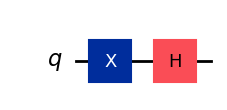

In [10]:
# Let's apply an H-gate on a |0> qubit
qc = QuantumCircuit(1)
qc.x(0)
qc.h(0)
qc.draw(output='mpl')

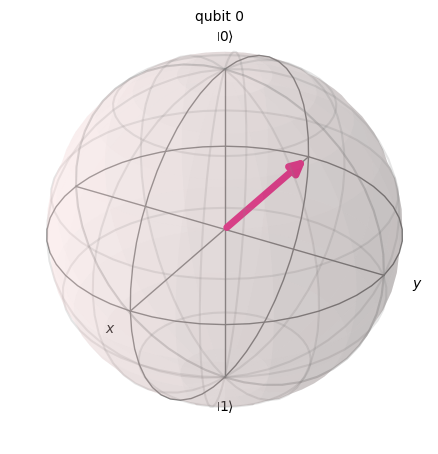

In [11]:
# Let's see Bloch sphere visualization
sv = Statevector(qc)
plot_bloch_multivector(sv)

### CX Gate (CNOT Gate)
The controlled NOT (or CNOT or CX) gate acts on two qubits. It performs the NOT operation (equivalent to applying an X gate) on the second qubit only when the first qubit is $|1\rangle$ and otherwise leaves it unchanged. Note: Qiskit numbers the bits in a string from right to left.

$CX = \begin{pmatrix}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0\\
0 & 0 & 0 & 1\\
0 & 0 & 1 & 0\\
\end{pmatrix}$

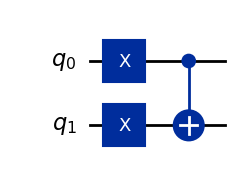

In [12]:
# Let's apply a CX-gate on |11>
qc = QuantumCircuit(2)
qc.x(0)
qc.x(1)
qc.cx(0,1)
qc.draw(output='mpl')

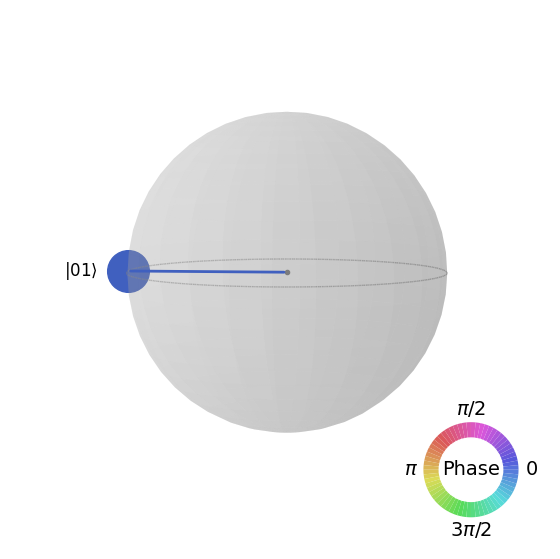

In [13]:
sv=Statevector(qc)
plot_state_qsphere(sv)

Create the first Bell state

$$ |\phi^+ \rangle = \frac{1}{\sqrt 2}(|00 \rangle + |11 \rangle) $$


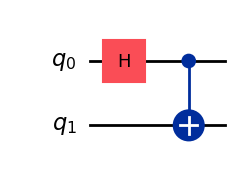

In [14]:
# Create a Bell state circuit

qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0,1)

# Draw the circuit
qc.draw("mpl")

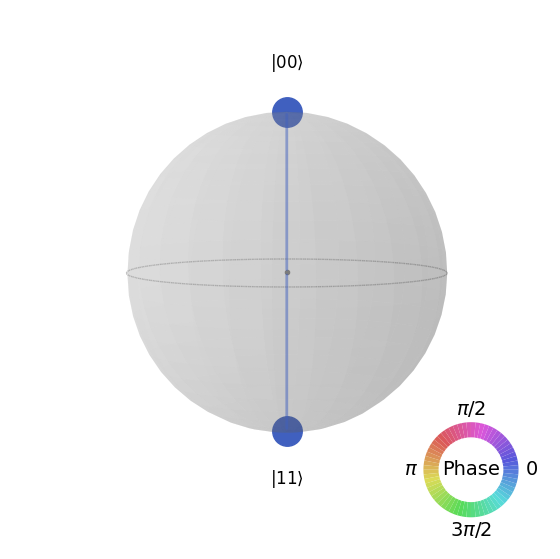

In [15]:
# Plot the state using q-sphere visualization
sv = Statevector(qc)
plot_state_qsphere(sv)
# q-sphere is useful for visualizing states when Bloch sphere fails to

Create the second Bell state

$$ |\phi^- \rangle = \frac{1}{\sqrt 2}(|00 \rangle - |11 \rangle) $$



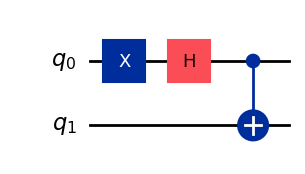

In [16]:
# Create a circuit with the second Bell state

qc = QuantumCircuit(2)
qc.x(0)
qc.h(0)
qc.cx(0,1)

qc.draw("mpl")

The explanation is that:
$$
|-\rangle=H|1\rangle= \frac{1}{\sqrt{2} }(|0\rangle-|1\rangle)
$$

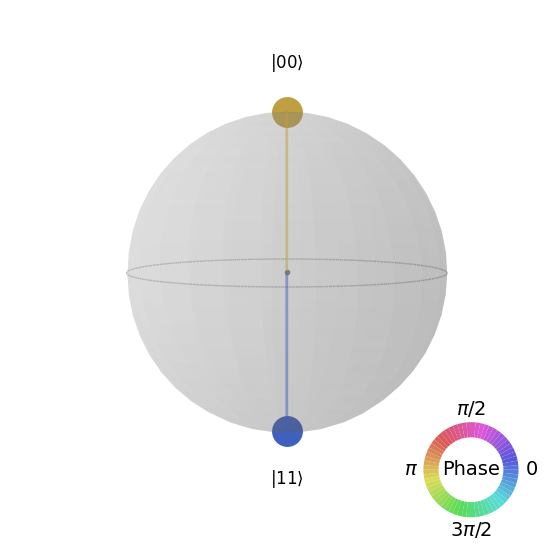

In [17]:
# Get the statevector of the circuit
sv = Statevector(qc)

# Plot the state using qsphere visualization
plot_state_qsphere(sv)

Create the 3-qubit GHZ state

$$ |GHZ \rangle = \frac{1}{\sqrt 2}(|000 \rangle + |111 \rangle) $$



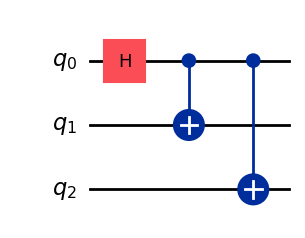

In [18]:
# Create a circuit with 3-qubit GHZ state

qc= QuantumCircuit(3)
qc.h(0)
qc.cx(0,1)
qc.cx(0,2)


qc.draw("mpl")

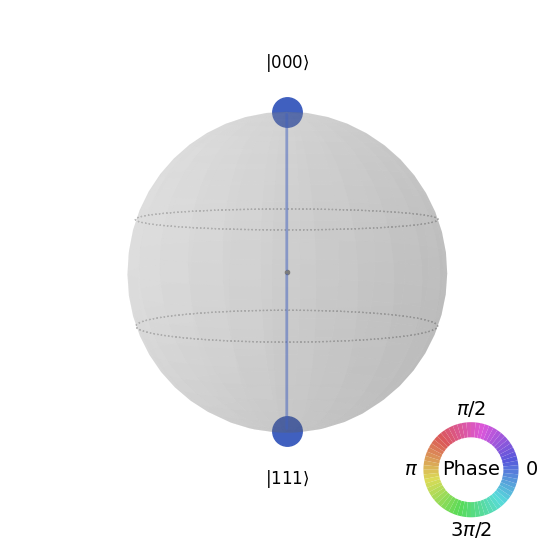

In [19]:
# Get the statevector of the circuit
sv = Statevector(qc)

# Plot the state using qsphere visualization
plot_state_qsphere(sv)

Create Qiskit logo state

$$ |Qiskit \rangle = \frac{1}{\sqrt 2}(|0010 \rangle + |1101 \rangle) $$




<div align="center">

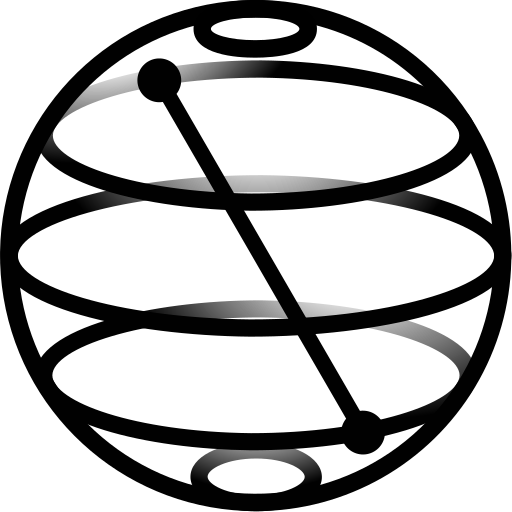

</div>


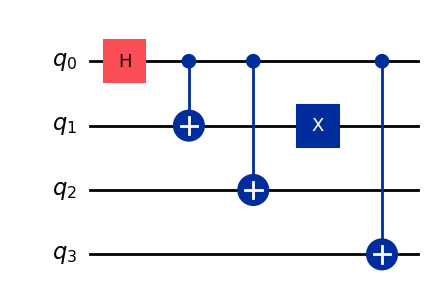

In [20]:
# Create a circuit with the Qiskit logo state


qc = QuantumCircuit(4)
qc.h(0)
qc.cx(0,1)
qc.cx(0,2)
qc.cx(0,3)
qc.x(1)


# Draw the circuit
qc.draw("mpl")

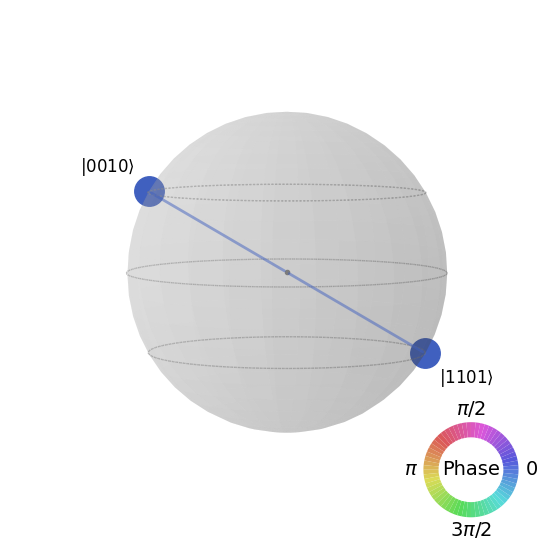

In [21]:
# Get the statevector of the circuit
sv = Statevector(qc)

# Plot the state using qsphere visualization
plot_state_qsphere(sv)

# 2. Create and run a simple quantum program



The four steps to writing a quantum program using Qiskit patterns are:

1.  Map the problem to a quantum-native format.

2.  Optimize the circuits and operators.

3.  Execute using a quantum primitive function.

4.  Analyze the results.

## 2.1 Map the problem to a quantum-native format

In a quantum program, *quantum circuits* are the native format in which to represent quantum instructions, and *operators* represent the observables to be measured. When creating a circuit, you'll usually create a new [`QuantumCircuit`](https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.QuantumCircuit#quantumcircuit-class) object, then add instructions to it in sequence.



The following code cell creates a circuit that produces the GHZ state which is a state wherein three qubits are fully entangled with each other.

<div class="alert alert-info">

  The Qiskit SDK uses the LSb 0 bit numbering where the $n^{th}$ digit has value $1 \ll n$ or $2^n$. For more details, see the [Bit-ordering in the Qiskit SDK](https://docs.quantum.ibm.com/guides/bit-ordering) topic.

</div>



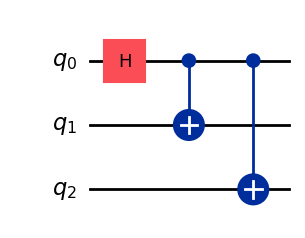

In [22]:
# Create a GHZ state circuit

qc = QuantumCircuit(3)
qc.h(0)
qc.cx(0,1)
qc.cx(0,2)
# Draw the circuit
qc.draw("mpl")

See [`QuantumCircuit`](https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.QuantumCircuit#quantumcircuit-class) in the documentation for all available operations.



When creating quantum circuits, you must also consider what type of data you want returned after execution. Qiskit provides two ways to return data: you can obtain a probability distribution for a set of qubits you choose to measure, or you can obtain the expectation value of an observable. Prepare your workload to measure your circuit in one of these two ways with [Qiskit primitives](https://docs.quantum.ibm.com/guides/get-started-with-primitives) (explained in detail in Step 3).

This example measures expectation values by using the `qiskit.quantum_info` submodule, which is specified by using operators (mathematical objects used to represent an action or process that changes a quantum state). The following code cell creates six three-qubit Pauli operators: `ZZZ`, `ZZX`, `ZII`, `XXI`, `ZZI` and `III`.


In [23]:
# Set up six different observables.

observables_labels = ["ZZZ", "ZZX", "ZII", "XXI", "ZZI", "III"]

observables = [SparsePauliOp(label) for label in observables_labels]
print(observables)


[SparsePauliOp(['ZZZ'],
              coeffs=[1.+0.j]), SparsePauliOp(['ZZX'],
              coeffs=[1.+0.j]), SparsePauliOp(['ZII'],
              coeffs=[1.+0.j]), SparsePauliOp(['XXI'],
              coeffs=[1.+0.j]), SparsePauliOp(['ZZI'],
              coeffs=[1.+0.j]), SparsePauliOp(['III'],
              coeffs=[1.+0.j])]


<div class="alert alert-info">

  Here, something like the `ZZI` operator is a shorthand for the tensor product $Z\otimes Z\otimes I$, which means measuring Z on qubit 1 and Z on qubit 0 together, and obtaining information about the correlation between qubit 1 and qubit 0. Expectation values like this are also typically written as $\langle Z_1 Z_0 \rangle$.

  If the state is entangled, then the measurement of $\langle Z_1 Z_0 \rangle$ should be 1.

</div>



<span id="optimize" />

## 2.2 Optimize the circuits and operators

When executing circuits on a device, it is important to optimize the set of instructions that the circuit contains and minimize the overall depth (roughly the number of instructions) of the circuit. This ensures that you obtain the best results possible by reducing the effects of error and noise. Additionally, the circuit's instructions must conform to a backend device's [Instruction Set Architecture (ISA)](https://docs.quantum.ibm.com/guides/transpile#instruction-set-architecture) and must consider the device's basis gates and qubit connectivity.

The following code instantiates a real device to submit a job to and transforms the circuit and observables to match that backend's ISA.

If you have not previously saved your credentials, follow instructions [here](https://docs.quantum.ibm.com/guides/setup-channel#iqp) to authenticate with your API token.

In [28]:
service = QiskitRuntimeService()
backend = service.least_busy(
    simulator=False, operational=True, min_num_qubits=100
)
print(f"Using backend: {backend.name}")

Using backend: ibm_torino


In [29]:
seed_sim=42
backend=AerSimulator.from_backend(backend,seed_simulator=seed_sim)

Transpile the circuit into ISA circuit

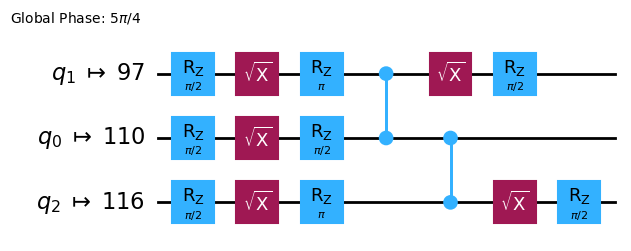

In [30]:
# Convert to an ISA circuit and layout-mapped observables.

pm = generate_preset_pass_manager(backend=backend, optimization_level=2)
isa_circuit = pm.run(qc) 

isa_circuit.draw("mpl", idle_wires=False)

In [31]:
mapped_observables = [
    observable.apply_layout(isa_circuit.layout) for observable in observables
]
print(mapped_observables)

[SparsePauliOp(['IIIIIIIIIIIIIIIIZIIIIIZIIIIIIIIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII'],
              coeffs=[1.+0.j]), SparsePauliOp(['IIIIIIIIIIIIIIIIZIIIIIXIIIIIIIIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII'],
              coeffs=[1.+0.j]), SparsePauliOp(['IIIIIIIIIIIIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII'],
              coeffs=[1.+0.j]), SparsePauliOp(['IIIIIIIIIIIIIIIIXIIIIIIIIIIIIIIIIIIXIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII'],
              coeffs=[1.+0.j]), SparsePauliOp(['IIIIIIIIIIIIIIIIZIIIIIIIIIIIIIIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII'],
              coeffs=[1.+0.j]), SparsePauliOp(['IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII

## 2.3 Execute using the quantum primitives

Quantum computers can produce random results, so you usually collect a sample of the outputs by running the circuit many times. You can estimate the value of the observable by using the `Estimator` class. `Estimator` is one of two [primitives](https://docs.quantum.ibm.com/guides/get-started-with-primitives); the other is `Sampler`, which can be used to get data from a quantum computer.  These objects possess a `run()` method that executes the selection of circuits, observables, and parameters (if applicable), using a [primitive unified bloc (PUB).](https://docs.quantum.ibm.com/guides/primitives#sampler)

When running this code on real quantum hardware, consider applying [error mitigation and suppression techniques](https://quantum.cloud.ibm.com/docs/en/guides/error-mitigation-and-suppression-techniques) to reduce the quantum computer's intrinsic noise.

In [32]:
# Construct the Estimator instance.
estimator = Estimator(mode=backend)
estimator.options.resilience_level = 1
estimator.options.default_shots = 5000

Submit a job using the Estimator primitive.


In [33]:
# One pub, with one circuit to run against six different observables.
job = estimator.run([(isa_circuit, mapped_observables)]) 


# Use the job ID to retrieve your job data later
print(f">>> Job ID: {job.job_id()}")

>>> Job ID: 97ecd036-1767-49b0-a1dc-c71638c3c3c4


/Users/jma/miniconda3/envs/3122/lib/python3.12/site-packages/qiskit_ibm_runtime/fake_provider/local_service.py:187: UserWarning: The resilience_level option has no effect in local testing mode.
  warnings.warn("The resilience_level option has no effect in local testing mode.")


After a job is submitted, you can wait until either the job is completed within your current python instance, or use the `job_id` to retrieve the data at a later time.  (See the [section on retrieving jobs](https://docs.quantum.ibm.com/guides/monitor-job#retrieve-job-results-at-a-later-time) for details.)

After the job completes, examine its output through the job's `result()` attribute.



In [34]:
# This is the result of the entire submission.  You submitted one Pub,
# so this contains one inner result (and some metadata of its own).
job_result = job.result()

# This is the result from our single pub, which had six observables,
# so contains information on all six.
pub_result = job.result()[0]

Now we can also execute the circuit using the `Sampler` primitive

In [35]:
# We include the measurements in the circuit
qc.measure_all()
sampler = Sampler(mode=backend)

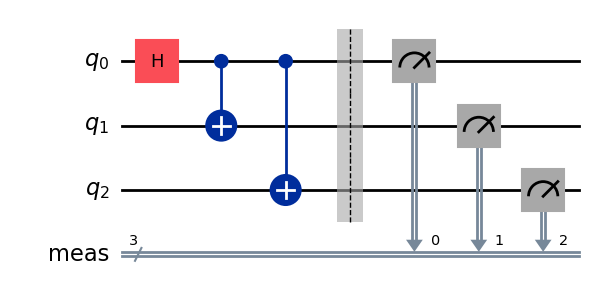

In [36]:
qc.draw(output="mpl")

Submit a job using the Sampler primitive.

In [37]:
job_sampler = sampler.run(pm.run([qc]))

# Use the job ID to retrieve your job data later
print(f">>> Job ID: {job_sampler.job_id()}")
# Get the results
results_sampler = job_sampler.result()

>>> Job ID: a6ee4d2f-c80d-4a86-9a76-e4b1a74502e7


## 2.4 Analyze the results

The analyze step is typically where you might postprocess your results using, for example, measurement error mitigation or zero noise extrapolation (ZNE). You might feed these results into another workflow for further analysis or prepare a plot of the key values and data. In general, this step is specific to your problem.  For this example, plot each of the expectation values that were measured for our circuit.

The expectation values and standard deviations for the observables you specified to Estimator are accessed through the job result's `PubResult.data.evs` and `PubResult.data.stds` attributes. To obtain the results from Sampler, use the `PubResult.data.meas.get_counts()` function, which will return a `dict` of measurements in the form of bitstrings as keys and counts as their corresponding values. For more information, see [Get started with Sampler.](https://docs.quantum.ibm.com/guides/get-started-with-primitives#get-started-with-sampler)



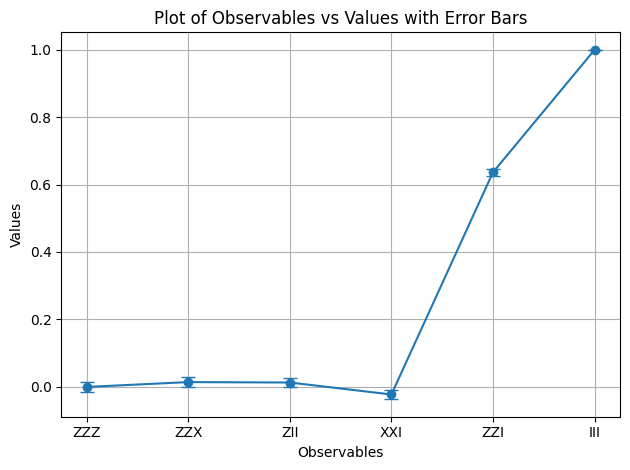

In [38]:
# Plot the result
from matplotlib import pyplot as plt
values = pub_result.data.evs
errors = pub_result.data.stds
# plotting graph
# Plotting with error bars
plt.errorbar(observables_labels, values, yerr=errors, fmt='-o', capsize=5)
plt.xlabel("Observables")
plt.ylabel("Values")
plt.title("Plot of Observables vs Values with Error Bars")
plt.grid(True)
plt.tight_layout()
plt.show()

We see that the observables $ZZI$ and $III$ have an expectation value of 1, since $ZZI$ introduces two minus signs that cancel out, and $III$ acts as the identity, leaving the GHZ state unchanged. The rest of the observables have an expectation value of 0, since their $Z$ operators introduce an odd number of minus signs, or the $X$ operators flip a number of qubits that make the overlapping states orthogonal.



Now we plot the results for the Sampler

{'111': 480, '000': 503, '101': 8, '100': 9, '001': 3, '011': 6, '010': 10, '110': 5}
Outcomes : {'111': 480, '000': 503, '101': 8, '100': 9, '001': 3, '011': 6, '010': 10, '110': 5}


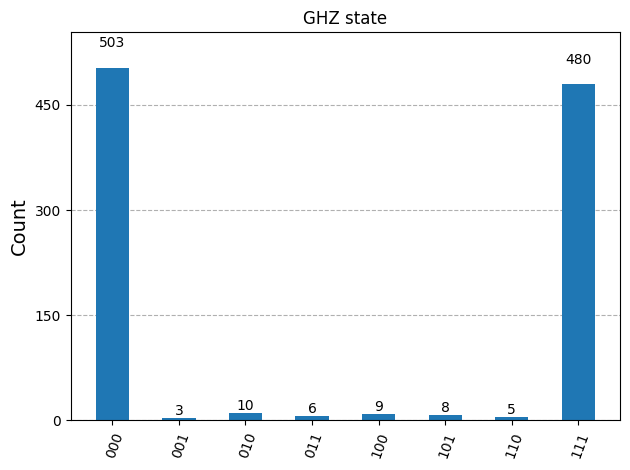

In [39]:
counts_list = results_sampler[0].data.meas.get_counts()
print(counts_list)
print(f"Outcomes : {counts_list}")
display(plot_histogram(counts_list, title="GHZ state"))

## 2.5 Scale to large numbers of qubits

In quantum computing, utility-scale work is crucial for making progress in the field. Such work requires computations to be done on a much larger scale; working with circuits that might use over 100 qubits and over 1000 gates. This example takes a small step in that direction scaling the GHZ problem to $n=10$ qubits.  It uses the Qiskit patterns workflow and ends by measuring the expectation value $\langle Z_0 Z_i \rangle $ for each qubit.

### Step 1. Map the problem

Write a function that returns a `QuantumCircuit` that prepares an $n$-qubit GHZ state (essentially an extended Bell state), then use that function to prepare a 10-qubit GHZ state and collect the observables to be measured.


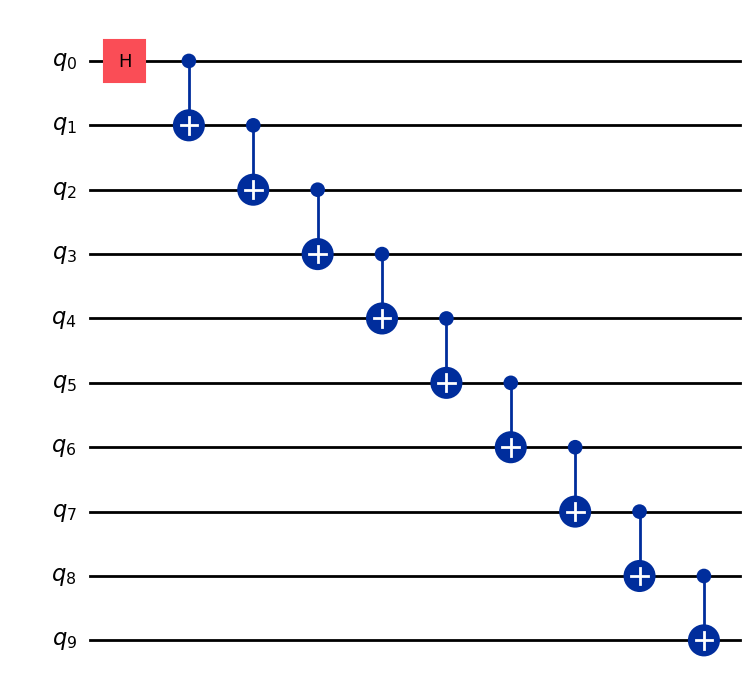

In [40]:
def get_qc_for_n_qubit_GHZ_state(n: int) -> QuantumCircuit:

    qc = QuantumCircuit(n) 
    qc.h(0)
    for i in range(n-1):
        qc.cx(i, i+1)
    return qc
n = 10
qc_n_GHZ = get_qc_for_n_qubit_GHZ_state(n)
qc_n_GHZ.draw("mpl")

Next, map to the operators of interest. This example uses the `ZZ` operators between qubits to examine the behavior as they get farther apart.  Increasingly inaccurate (corrupted) expectation values between distant qubits would reveal the level of noise present.


In [41]:
# ZZII...II, ZIZI...II, ... , ZIII...IZ
operator_strings = [
    "Z" + i * "I" + "Z" + "I" * (n-i-2) for i in range(n-1) 
]
print(operator_strings)
print(len(operator_strings))

operators = [SparsePauliOp(operator) for operator in operator_strings]

['ZZIIIIIIII', 'ZIZIIIIIII', 'ZIIZIIIIII', 'ZIIIZIIIII', 'ZIIIIZIIII', 'ZIIIIIZIII', 'ZIIIIIIZII', 'ZIIIIIIIZI', 'ZIIIIIIIIZ']
9


### Step 2. Optimize the problem for execution on quantum backend

Transform the circuit and observables to match the backend's ISA.



In [42]:
# Convert to an ISA circuit and layout-mapped observables.
pm = generate_preset_pass_manager(backend=backend, optimization_level=2)
isa_circuit = pm.run(qc_n_GHZ) 
isa_operators_list = [operator.apply_layout(isa_circuit.layout) for operator in operators] 

### Step 3. Execute on backend

Submit the job and if you execute it on hardware enable error suppression by using a technique to reduce errors called [dynamical decoupling.](https://docs.quantum.ibm.com/api/qiskit-ibm-runtime/options-dynamical-decoupling-options) The resilience level specifies how much resilience to build against errors. Higher levels generate more accurate results, at the expense of longer processing times.  For further explanation of the options set in the following code, see [Configure error mitigation for Qiskit Runtime.](https://docs.quantum.ibm.com/guides/configure-error-mitigation)



In [43]:
# Submit the circuit to Estimator
job = estimator.run([(isa_circuit, isa_operators_list)])
job_id = job.job_id()

/Users/jma/miniconda3/envs/3122/lib/python3.12/site-packages/qiskit_ibm_runtime/fake_provider/local_service.py:187: UserWarning: The resilience_level option has no effect in local testing mode.
  warnings.warn("The resilience_level option has no effect in local testing mode.")


### Step 4. Post-process results

To better understand the behavior of entangled quantum states on real hardware, we analyze the pairwise correlations between qubits in the Z basis. Specifically, we look at the expectation values ⟨Z₀Zᵢ⟩, which measure how strongly qubit 0 is correlated with each other qubit i. In particular we are going to plot: 
$$
\langle Z_i Z_0 \rangle / \langle Z_1 Z_0 \rangle 
$$

<div class="alert alert-success">

Which values of $\langle Z_i Z_0 \rangle / \langle Z_1 Z_0 \rangle $ do you expect to see in the plot?

Options:

a) Decreasing as we increase $i$

b) Constant in 1

c) Small deviations around 1

d) Alternating 1 and 0 for odd and even values of $i$

</div>

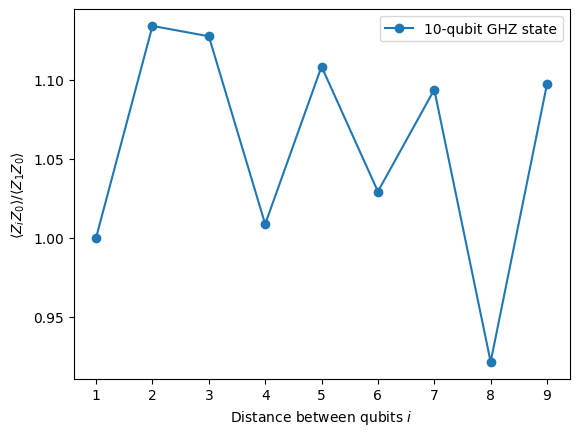

In [44]:
data = list(range(1, len(operators) + 1))  # Distance between the Z operators
result = job.result()[0]
values = result.data.evs  # Expectation value at each Z operator.
values = [
    v / values[0] for v in values
]  # Normalize the expectation values to evaluate how they decay with distance.

plt.plot(data, values, marker="o", label=f"{n}-qubit GHZ state")
plt.xlabel("Distance between qubits $i$")
plt.ylabel(r"$\langle Z_i Z_0 \rangle / \langle Z_1 Z_0 \rangle $")
plt.legend()
plt.show()

In this plot we notice that $\langle Z_0 Z_i \rangle$ fluctuates around the value 1, even though in an ideal simulation all $\langle Z_0 Z_i \rangle$ should be 1.



As you can see, the results of 10 qubit experiments are good but still have some errors. One way to improve the results is to implement GHZ state more efficiently. 

Usually one implements GHZ state with a staircase-like CNOT gates sequence. However, you can implement GHZ state more efficiently, reducing the 2-qubit depth from `n` to `n/2` or less.

<div class="alert alert-info">

One important metric to benchmark how accurate the results will be, or how little noise will have for a circuit is 2-qubit gate depth. This is because the error rates for 2-qubit gates (~10 times higher than single qubit gates) dominate the errors of the whole circuit. Use the following code to get 2-qubit gate depth of a circuit.

```
qc.depth(lambda x: x.operation.num_qubits == 2)
```

</div>

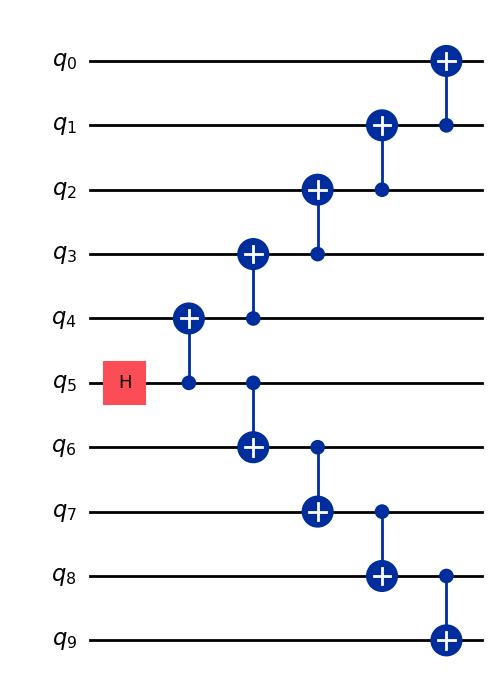

In [46]:
def better_ghz(n):
    "fan out"
    s = int(n / 2)
    qc = QuantumCircuit(n)
    qc.h(s)
    for m in range(s, 0, -1):
        qc.cx(m, m - 1)
        if not (n % 2 == 0 and m == s): 
            qc.cx(n - m - 1, n - m)
    return qc


better_ghz(n).draw("mpl")

In [47]:
# Check 2-qubit gate depth before transpilation
qc_better_ghz = better_ghz(n)
qc_better_ghz.depth(lambda x: x.operation.num_qubits == 2)

5

An interesting thing to note here is that we were able to reduce the [**quantum depth**](https://www.youtube.com/watch?v=7AVIc7SkX3M) of the circuit we want to execute just by being smart and thinking of a different way to program it. However, there will be situations and algorithms where we can't rely on these clever tricks. This is where the transpiler comes in handy, it helps us optimize all these aspects efficiently, so we don't have to worry too much about them.

# 3. Encoding Information

## 3.1 Amplitude encoding

Now that we've seen how to build quantum circuits, it is interesting to explore how we can encode classical information into quantum states. One powerful method is, amplitude encoding, where the amplitudes of a quantum state represent the components of a classical vector.

Let's consider a simple example. Suppose we want to encode the classical vector

$$
\vec{x} = \begin{bmatrix} x_0 \\ x_1 \\ x_2 \\ x_3 \end{bmatrix}
$$

into a quantum state of two qubits. The goal is to prepare the quantum state:

$$
\ket{\psi} = x_0\ket{00} + x_1\ket{01} + x_2\ket{10} + x_3\ket{11}
$$
where $ x_0, x_1, x_2, x_3 \in \mathbb{R} $ (or $ \mathbb{C} $) and the vector is normalized such that:

$$
|x_0|^2 + |x_1|^2 + |x_2|^2 + |x_3|^2 = 1
$$

Now we consider the particular example: $ \vec{x} = [0.8924,  0.3696, 0.2391, 0.0990] $

Then the corresponding quantum state is:

$$
\begin{aligned}
\ket{\psi} &= 0.8924\,\ket{00}
+ 0.3696\,\ket{01}
+ 0.2391\,\ket{10}
+ 0.0990\,\ket{11}
\end{aligned}
$$
This state can be prepared using a combination of rotation gates $R_y$ of angles $\pi/6$ and $\pi/4$ for qubits 0 and 1 respectively


Statevector: Statevector([0.8923991 +0.j, 0.23911762+0.j, 0.36964381+0.j,
             0.09904576+0.j],
            dims=(2, 2))


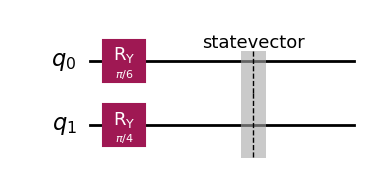

In [48]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import numpy as np

qc = QuantumCircuit(2)

qc.ry(np.pi / 6, 0)
qc.ry(np.pi / 4, 1)

simulator = AerSimulator()
qc.save_statevector()
result = simulator.run(qc).result()
statevector = result.get_statevector()

print("Statevector:", statevector)
qc.draw(output="mpl")


Statevector: Statevector([0.89242154+0.j, 0.36960892+0.j, 0.23910577+0.j,
             0.09900239+0.j],
            dims=(2, 2))


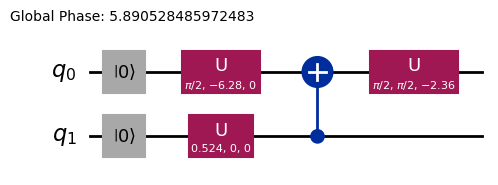

In [49]:
from qiskit.quantum_info import Statevector

# Define our vector
v = np.array([0.8924,  0.3696, 0.2391, 0.0990]) 
v = v/np.linalg.norm(v)
# Create a statevector from the vector
state = Statevector(v)

# Initialize a quantum circuit with 2 qubits
qc = QuantumCircuit(2)
qc.initialize(state.data, [0, 1])


# Optional: simulate the state
print("Statevector:", state)

# Visualize the circuit
qc.decompose().decompose().decompose().decompose().decompose().draw("mpl")

Hence we have seen how to encode information using rotational gates.

## 3.2 Angle encoding and parametrized circuits

A particularly interesting way of encoding information into a quantum computer is designing a quantum circuit that contains some rotational angles $\vec{\theta}$ or parameters that can be tuned in order to represent a family of functions $f(\vec{\theta})$. Let us for example consider the following parametrized quantum circuit:

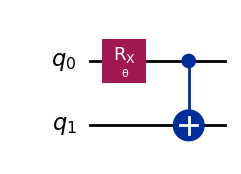

In [44]:
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter

# Define a symbolic parameter
theta = Parameter("θ")

qc = QuantumCircuit(2)
# We applied a parametrized RX gate
qc.rx(theta, 0)
qc.cx(0, 1)
qc.draw("mpl")


Mathematically, we can analyze what is the family of functions we can represent with this circuit:

$$ 
\text{CNOT}_{01} \, R_x^{\{0\}}(\theta) |00\rangle = \text{CNOT}_{01} \left( \cos(\theta/2)\ket{00} - i\sin(\theta/2)\ket{10} \right) = \cos(\theta/2)\ket{00} - i\sin(\theta/2)\ket{11}
$$

It is pretty clear that the number of states we can represent with this quantum circuit is limited, as we cannot represent states $\ket{10}$ or $\ket{01}$ for example. However, the family of states we can represent starts to grow when we introduce more rotations in the adequate places:

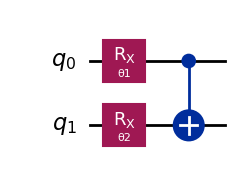

In [45]:
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter

# Define a symbolic parameter
theta1 = Parameter("θ1")
theta2 = Parameter("θ2")

qc = QuantumCircuit(2)
qc.rx(theta1, 0)
qc.rx(theta2, 1)
qc.cx(0, 1)
qc.draw("mpl")


In this case, the quantum states we will represent are:

\begin{align*}
\text{CNOT}_{01} \, R_x^{\{1\}}(\theta_2) R_x^{\{0\}}(\theta_1) \ket{00}
&= \text{CNOT}_{01} \, R_x^{\{1\}}(\theta_2)\left( \cos(\theta_1/2)\ket{00} - i\sin(\theta_1/2)\ket{10} \right) \\
&= \text{CNOT}_{01}\left( \cos(\theta_1/2)\cos(\theta_2/2)\ket{00} - i\cos(\theta_1/2)\sin(\theta_2/2)\ket{01} \right. \\
&\quad \left. - i\sin(\theta_1/2)\cos(\theta_2/2)\ket{10} + \sin(\theta_1/2)\sin(\theta_2/2)\ket{11} \right) \\
&= \cos(\theta_1/2)\cos(\theta_2/2)\ket{00} - i\cos(\theta_1/2)\sin(\theta_2/2)\ket{01} \\
&\quad + \sin(\theta_1/2)\sin(\theta_2/2)\ket{10} - i\sin(\theta_1/2)\cos(\theta_2/2)\ket{11} 
\end{align*}

We can see that this circuit generates a broader family of quantum states compared to the previous one. In particular, it can now produce states with non-zero amplitudes for $\ket{01}$ or $\ket{10}$ that were not possible with the circuit above. However, this circuit is still not a universal quantum state generator, although it may be sufficiently expressive to design circuits with some flexibility for representing certain functions. In general, the more independent parameters (angles) we introduce, the more expresiveness the circuit has to approximate arbitrary quantum states.

## Ansatzes and Circuit library

This kind of parameterized quantum circuit can be used to build [Ansatzes](https://quantum.cloud.ibm.com/learning/en/courses/quantum-chem-with-vqe/ansatz), trial quantum states that aim to approximate the solution of a problem. These Ansatzes are a central component of [Variational Quantum Algorithms](https://quantum.cloud.ibm.com/learning/en/courses/variational-algorithm-design/variational-algorithms), a class of hybrid quantum-classical algorithms that use a quantum computer to evaluate a cost function and a classical optimizer to minimize it. We will go into detail about these topics in a later Unit, but for now, we will introduce how to construct a simple ansatz using the [Circuit library in Qiskit](https://quantum.cloud.ibm.com/docs/en/api/qiskit/circuit_library). 

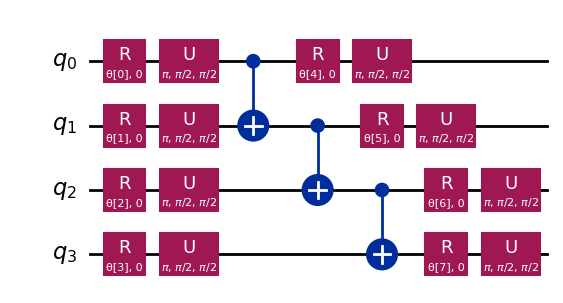

In [46]:
from qiskit.circuit.library import efficient_su2

SU2_ansatz = efficient_su2(4, su2_gates=["rx", "y"], entanglement="linear", reps=1)
SU2_ansatz.decompose().draw(output="mpl")

We have seen how to construct a simple Ansatz using the `efficient_su2` function of the `qiskit.circuit.library` that will be able to generate a wide range of quantum states by tuning its parameters $\vec{\theta}$.

# Conclusion

In this notebook, you have learned how to construct quantum circuits, from building quantum gates to defining and measuring observables, and how to execute these circuits efficiently on both simulators and actual quantum hardware. You have also seen the importance of careful circuit design in order to minimize errors when working with real quantum devices as well as strategies for scaling circuits to larger numbers of qubits, particularly through the GHZ state example. Furthermore, you have explored different techniques for encoding classical information into quantum states, including amplitude encoding and angle encoding. With all this, you are fully equipped to jump to the next session and start working with quantum algorithms.

## Installing Qiskit Code Assistant in VSCode
Click the [link](https://quantum.cloud.ibm.com/docs/en/guides/qiskit-code-assistant-vscode) and follow the instructions.



# Bonus: Quantum Teleportation

When you hear the term quantum teleportation, you might imagine futuristic sci-fi technology that disintegrates an object in one place and reappears it somewhere far away. But quantum teleportation is nothing like that. In reality, what gets teleported is not matter, it's information.

Quantum teleportation allows the transfer of the quantum state of a qubit from one location to another. While this transfer appears instantaneous, it does not violate the laws of physics.  How is that possible? Let's dig in!

Quantum teleportation is a protocol that allows a sender (Alice) to transmit the state $|\psi\rangle$ of a qubit `q` to a receiver (Bob) using two key resources: a shared entangled pair of qubits `a` and `b` and two bits of classical communication `c0` and `c1`. 

Essentially what the protocol needs is:
*   `q`: Alice's qubit, initially in the state $|\psi\rangle$ we want to teleport.
*   `a`: Alice's half of a shared entangled pair.
*   `b`: Bob's half of the shared entangled pair.
*   `c0`, `c1`: Classical bits to store Alice's measurement results.

And how does it work? The workflow is the following

1.  **Prepare Alice's state $|\psi\rangle$ on `q`.** We'll create a specific state like $|+\rangle$ for verification.
2.  **Create entanglement:** Generate a Bell pair between `a` and `b`.
3.  **Alice's operations:** Alice performs a "Bell measurement" on her two qubits (`q` and `a`) and stores the classical results in `c0` and `c1`.
4.  **Classical communication:** Alice sends her two classical bits (`c0`, `c1`) to Bob.
5.  **Bob's corrections:** Bob applies specific quantum gates (X and/or Z) to his qubit (`b`), conditioned on the values of `c0` and `c1` he received.

If everything is done correctly, Bob's qubit `b` will end up in the state $|\psi\rangle$, the original state of Alice's `q`!

For a more in-depth explanation and exploration of quantum teleportation, including going through the mathematical explanation of why this protocol works, you can refer to the IBM Quantum Learning resources: [Quantum Teleportation](https://quantum.cloud.ibm.com/learning/courses/basics-of-quantum-information/entanglement-in-action/quantum-teleportation). This is part of the [Basics of Quantum Information](https://quantum.cloud.ibm.com/learning/courses/basics-of-quantum-information) course.

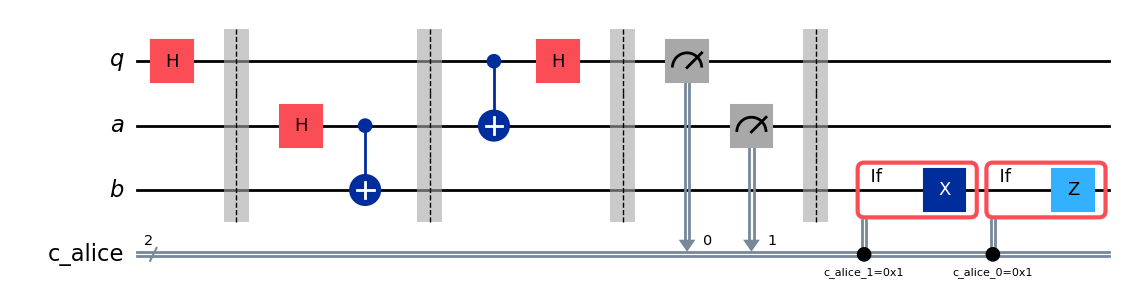

In [ ]:

import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_bloch_multivector

# Define individual quantum registers for each qubit
q = QuantumRegister(1, name='q')  # message qubit
a = QuantumRegister(1, name='a')  # Alice's entangled qubit
b = QuantumRegister(1, name='b')  # Bob's entangled qubit

# Classical register for Alice's measurements
cr_alice = ClassicalRegister(2, name='c_alice')

# Create quantum circuit
teleport_qc = QuantumCircuit(q, a, b, cr_alice, name='Teleportation')

# Step 1: Prepare message state |+⟩ on q
teleport_qc.h(q[0])
teleport_qc.barrier()

# Step 2: Create entanglement between a and b
teleport_qc.h(a[0])
teleport_qc.cx(a[0], b[0])
teleport_qc.barrier()

# Step 3: Alice's Bell measurement
teleport_qc.cx(q[0], a[0])
teleport_qc.h(q[0])
teleport_qc.barrier()

# Step 4: Alice measures q and a
teleport_qc.measure(q[0], cr_alice[0])
teleport_qc.measure(a[0], cr_alice[1])
teleport_qc.barrier()

# Step 5: Bob's conditional measurements
with teleport_qc.if_test((cr_alice[1], 1)):
    teleport_qc.x(b[0])
with teleport_qc.if_test((cr_alice[0], 1)):
    teleport_qc.z(b[0])

# Draw the circuit
teleport_qc.draw(output='mpl')


After executing the protocol a key question arises, how do we verify that the teleportation worked? We can't directly 'see' the state of Bob's qubit after the protocol. However, since we *prepared* Alice's initial state $|\psi\rangle$ (we chose $|+\rangle$), we can use a special type of simulation to check if Bob's qubit `b` ended up in that same state.

We'll use `AerSimulator` with `save_statevector` to check if Bob's qubit `b` ends up in Alice's original state ($|+\rangle$). This simulator calculates the final quantum state vector.
and then represents it using `plot_bloch_multivector` to visualize Bob's qubit (`b`) compared to Alice's initial state (`q`).


Visualizing final qubit states:


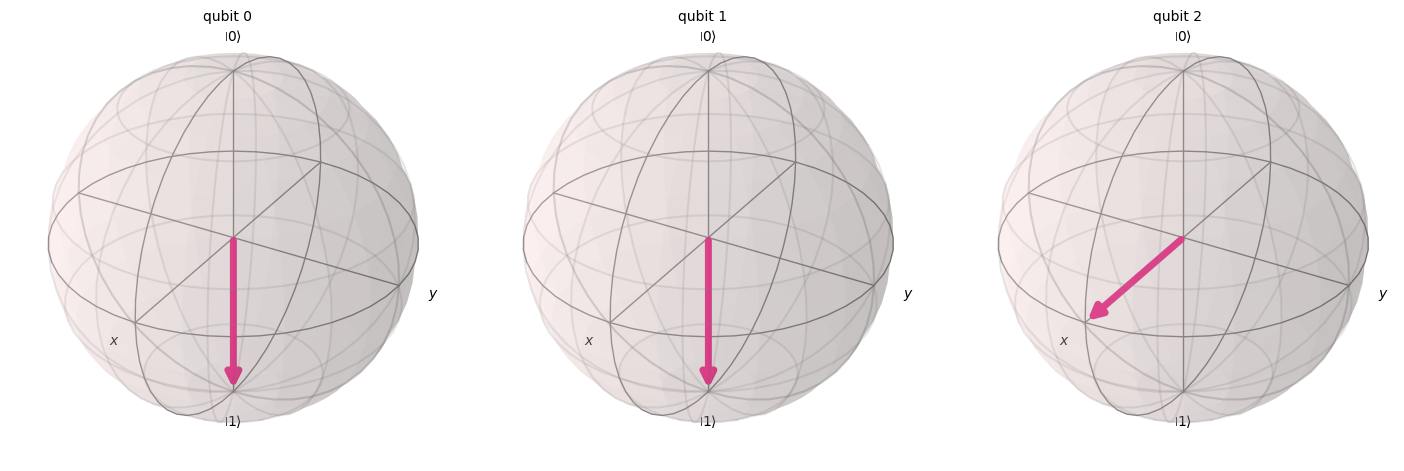

Note that Alice's qubits have collapsed to |00⟩, |01⟩, |10⟩, or |11⟩, while Bob's qubit is in the original state |+⟩.


In [48]:
# Simulate the teleportation circuit
sv_simulator = AerSimulator(method='statevector')
teleport_qc_sv = teleport_qc.copy()
teleport_qc_sv.save_statevector()

# Execute the circuit on the statevector simulator
job_sv = sv_simulator.run(teleport_qc_sv)
result_sv = job_sv.result()

# Get the final statevector
final_statevector = result_sv.get_statevector()
print("Visualizing final qubit states:")
display(plot_bloch_multivector(final_statevector))
print("Note that Alice's qubits have collapsed to |00⟩, |01⟩, |10⟩, or |11⟩, while Bob's qubit is in the original state |+⟩.")

As we can see from the visualization, the first two qubits (belonging to Alice) have collapsed to 0 or 1. Meanwhile, the third qubit (belonging to Bob), represented in the third Bloch sphere, points along the x-axis, indicating it is in the state $|+\rangle$, so we have successfully implemented the quantum teleportation protocol!

### Summary 

At this point it is convenient to make a quick summary of what we have accomplished:
- Alice has transmited an *unknown quantum state* to Bob.
- No physical particle has been transferred.
- The original state on Alice's qubit is destroyed, in accordance with the No-Cloning theorem.

However, quantum teleportation still needs of classical communication (Alice's measurement results sent to Bob), and that explains why this process doesn't allow faster-than-light information transfer and is fully consistent with all known laws of physics.